# 1. RQ2: SINGLE CHIP VALIDATION

In [1]:
import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder


def load_well_ids_and_labels(exp_path):
    """y_full/well_ids_full exactly as 03_main_training.py derives them. well_ids_full
    comes from the RAW (pre label-mapping) Y_well when metadata has no well_id column --
    deliberately independent of how config.LABEL_MAPPINGS later buckets labels."""
    training_data = joblib.load(exp_path / config.TRAINING_DATA_PATH)
    Y_well = training_data["Y_well"]
    metadata_df = pd.DataFrame(training_data["metadata"])
    well_ids_full = (metadata_df["well_id"].values if "well_id" in metadata_df.columns
                      else np.array(Y_well).copy())

    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name in label_mappings:
        mapping = label_mappings[exp_path.name]
        Y_well = [mapping.get(w, w) for w in Y_well]

    y_full = LabelEncoder().fit_transform(Y_well)
    return y_full, well_ids_full


def compute_filtered_test_split(y_full, well_ids_full, n_splits=1):
    """Reconstructs the None-filter + rare-class-drop + well-stratified split
    evaluate_outlier_filters used for outlier_filter=None. Returns (global_idx_of_test,
    well_ids_of_test), in the same order as the cached y_trues_/y_preds_AC_* arrays."""
    unique_classes, class_counts = np.unique(y_full, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_full, rare)
    y_v, w_v = y_full[valid], well_ids_full[valid]
    global_idx = np.where(valid)[0]

    n_classes = len(np.unique(y_v))
    if n_splits == 1:
        test_size = max(len(y_v) * 0.10, n_classes) / len(y_v)
        _, test_idx = build_well_stratified_random_split(y_v, w_v, test_size=test_size)["random_split"]
    else:
        _, test_idx = next(iter(build_well_stratified_nfold_splits(y_v, w_v, n_splits=n_splits).values()))

    return global_idx[test_idx], w_v[test_idx]


def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)


In [3]:
FAMILIES = [
            'cnn_gru_dual', 
            'cnn_gru_dual_attn_recon', 
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}
MODEL_KEY.update({
    ('cnn_gru_dual', 1):              'cnn_gru_dual_supcon',
    ('cnn_gru_dual_attn_recon', 1):   'cnn_gru_dual_attn_recon_supcon',
})

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}
MODEL_TO_SC = {MODEL_KEY[(fam, sc)]: sc for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────
def list_folders(exp_folder):
    out = []
    for name in sorted(os.listdir(exp_folder)):
        p = os.path.join(exp_folder, name)
        if (os.path.isdir(p) and name not in config.EXCLUDED_FOLDERS
                and os.path.exists(os.path.join(p, config.TRAINING_DATA_PATH))):
            # out.append((name, p))
            out.append(name)
    return out

PREP_DIRS = {
    'nc_subtract': '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract',
}
CURVE_JLIB = {
    'ori':          'Ori Curves',
    'ori_norm':     'Ori Curves Norm',
    'sgp4':         'Ori Curves Sg P4',
    'sgp4_norm':    'Ori Curves Sg P4 Norm',
}

TARGET_FOLDERS = list_folders(PREP_DIRS['nc_subtract'])[-4:]

def short_name(folder):
    return folder.split('_U_', 1)[1][:-3]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
# Standard model naming, shared across every section of this notebook (RQ2, RQ3.1, RQ3.2)
# and mirrored verbatim in 0_LOFO_INSPECTION.ipynb -- the single source of truth for how a
# model key is displayed on any chart.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_coral': 'CNN-BiGRU\n+ CORAL',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_coral': 'CNN-BiGRU + Spatial Attn\n+ CORAL',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',

    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'ccgd_arch_poc_st': 'CCGD-ST',
    'gnn_gat': 'GNN (GAT)',
    'gnn_gat_dann': 'GNN (GAT)\n+ DANN',
    'gnn_gat_coral': 'GNN (GAT)\n+ CORAL',
    'gnn_gat_supcon3': 'GNN (GAT)\n+ Contrastive Loss',

}
SC_LABELS   = {0: 'SC0', 1: 'SC1', 2: 'SC2', 3: 'SC3'}
PREP_LABELS = {'original': 'Original', 'nc_subtract': 'NC-Subtract'}
CURVE_LABELS = {'ori': 'Ori (raw)', 'ori_norm': 'Ori (norm)',
                'avg': 'Moving Avg', 'avg_norm': 'Moving Avg (norm)',
                'wavelet': 'Wavelet sym8', 'wavelet_norm': 'Wavelet sym8 (norm)',
                'bior35': 'Wavelet bior3.5', 'bior35_norm': 'Wavelet bior3.5 (norm)',
                'sgp4': 'SG p=4 (auto-w)', 'sgp4_norm': 'SG p=4 (norm)'}
METRIC_LABELS = {
    'accuracy':    'Accuracy',
    'f1':          'F1 macro',
    'auc':         'AUC-ROC',
    'sensitivity': 'Sensitivity',
    'specificity': 'Specificity',
}
METRICS = list(METRIC_LABELS)

# ── Colors ────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'cnn_gru_dual':              '#1f77b4',
    'cnn_gru_dual_cosine_recon': '#2ca02c',
    'cnn_gru_dual_attn_recon':   '#d62728',
    'ccgd_arch_poc_st':          '#9467bd',
}
SC_MARKERS = {0: 'o', 1: 's', 2: '^', 3: 'D'}
SC_LINES   = {0: '-', 1: '--', 2: ':', 3: '-.'}
PREP_COLORS  = {'original': '#4393c3', 'nc_subtract': '#d6604d'}
CURVE_COLORS = {
                'ori': '#4393c3', 'ori_norm': '#a6cee3',
                'avg': '#e08c00', 'avg_norm': '#f4b183',
                'wavelet': '#1a9850', 'wavelet_norm': '#a6d96a',
                'bior35': '#d6604d', 'bior35_norm': '#f4a582',
                'sgp4': '#7b2d8b', 'sgp4_norm': '#c994c7'
                }
# dataviz-skill validated categorical palette, assigned in a `models`-list's order --
# shared by every grouped-bar-by-model chart in this notebook (RQ2 and RQ3.1 alike).
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [4]:
TARGET_FOLDERS

['D20260806_E00_C00_F4500KHz_U_DDM_01_06',
 'D20260807_E00_C00_F4500KHz_U_DDM_02_07',
 'D20260808_E00_C00_F4500KHz_U_DDM_03_01',
 'D20260810_E00_C00_F4500KHz_U_DDM_04_01']

In [5]:
def compute_metrics(perf, model_key):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    return {'accuracy': acc, 'f1': f1, 'auc': auc,
            'sensitivity': sens, 'specificity': float(np.mean(specs))}


In [6]:
def load_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        for prep, base_dir in PREP_DIRS.items():
            path = Path(base_dir) / folder / 'classification_performances.joblib'
            if not path.exists():
                print(f'[WARN] missing {path}')
                continue
            data = joblib.load(path)
            for curve, jlib_key in CURVE_JLIB.items():
                perf = data.get(jlib_key, {}).get('Native', {}).get(None)
                if perf is None:
                    continue
                for model in MODELS:
                    m = compute_metrics(perf, model)
                    if m is None:
                        continue
                    rows.append(dict(dataset=dataset, preprocessing=prep,
                                     curve_type=curve, model=model,
                                     family=MODEL_TO_FAMILY[model],
                                     sc_level=MODEL_TO_SC[model], **m))
    return pd.DataFrame(rows)

df = load_all()
print(f"Loaded {len(df)} rows  |  "
      f"{df.dataset.nunique()} datasets  "
      f"{df.preprocessing.nunique()} preprocessing  "
      f"{df.curve_type.nunique()} curve types  "
      f"{df.model.nunique()} models")
df.head(4)


Loaded 24 rows  |  4 datasets  1 preprocessing  3 curve types  2 models


,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.930393,0.913073,0.992633,0.912648,0.986108
1,DDM_01,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
2,DDM_01,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.940209,0.924441,0.996013,0.920385,0.984448
3,DDM_01,nc_subtract,ori_norm,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
expected = len(MODELS)
check = (df.groupby(['dataset','preprocessing','curve_type'])
           .size()
           .reset_index(name='n')
           .assign(expected=expected, ok=lambda x: x.n == x.expected))
missing = check[~check.ok]
if missing.empty:
    print("All combinations fully populated.")
else:
    print("[!] Incomplete combinations:")
    display(missing)


All combinations fully populated.


In [8]:
datasets = df.dataset.unique()
CURVE_ORDER = list(CURVE_JLIB.keys())   # ['ori', 'avg', 'wavelet', 'bior35', 'sgp4']

for _FILTER_DATASET in datasets:
    print(f"===+++++++++++===")
    print(f"=== {_FILTER_DATASET} ===")
    print(f"===+++++++++++===")
    for _FILTER_PREP in df.preprocessing.unique():
        _sub = df[(df.dataset == _FILTER_DATASET) & (df.preprocessing == _FILTER_PREP)].copy()
        if _sub.empty:
            continue
        _sub['SC']     = _sub.sc_level.map(SC_LABELS)
        _sub['Family'] = _sub.family.map(FAMILY_LABELS)

        # Pivot: rows = (SC, Family), outer cols = metric, inner cols = curve_type
        _pivot = (
            _sub.set_index(['SC', 'Family', 'curve_type'])[METRICS]
            .stack()
            .rename('val')
            .reset_index()
            .pivot_table(index=['SC', 'Family'],
                        columns=['level_3', 'curve_type'],
                        values='val')
        )

        _curve_order  = [c for c in CURVE_ORDER if c in _sub.curve_type.unique()]
        _metric_order = METRICS
        _pivot = _pivot.reindex(
            columns=pd.MultiIndex.from_product([_metric_order, _curve_order])
        )
        _pivot.columns = pd.MultiIndex.from_tuples(
            [(METRIC_LABELS[m], CURVE_LABELS[c]) for m, c in _pivot.columns]
        )

        # Preserve SC / Family display order
        _sc_order  = [SC_LABELS[s]  for s in SC_LEVELS]
        _fam_order = [FAMILY_LABELS[f] for f in FAMILIES]
        _pivot = _pivot.reindex(
            pd.MultiIndex.from_product([_sc_order, _fam_order], names=['SC', 'Family'])
        )

        _pivot_pct = (_pivot * 100).round(2)

        def _col_gradient(col):
            mn, mx = col.min(), col.max()
            rng = mx - mn if mx > mn else 1e-9
            return [f'background-color: rgba(26,152,80,{0.12 + 0.72*(v - mn)/rng:.2f})'
                    for v in col]

        def _metric_borders(styler):
            for mi in range(len(_metric_order) - 1):
                last_col = (mi + 1) * len(_curve_order) - 1
                styler = styler.set_properties(
                    subset=pd.IndexSlice[:, _pivot_pct.columns[last_col]],
                    **{'border-right': '2px solid #555'}
                )
            return styler

        styled = (
            _pivot_pct.style
            .apply(_col_gradient, axis=0)
            .format("{:.2f}%")
            .set_caption(
                f"{_FILTER_DATASET}  |  {PREP_LABELS[_FILTER_PREP]}  "
                f"|  columns: metric → curve type"
            )
        )
        styled = _metric_borders(styled)
        display(styled)

===+++++++++++===
=== DDM_01 ===
===+++++++++++===


===+++++++++++===
=== DDM_02 ===
===+++++++++++===


===+++++++++++===
=== DDM_03 ===
===+++++++++++===


===+++++++++++===
=== DDM_04 ===
===+++++++++++===


In [9]:
def plot_accuracy_by_model(df, models, prep='nc_subtract', curve='ori', figsize=(6, 4)):
    """Grouped bar chart: x=dataset, one sub-bar per model (order = `models`), y=accuracy%."""
    sub = df[(df.preprocessing == prep) & (df.curve_type == curve)]
    datasets = DATASET_NAMES
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(datasets))

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        ys = np.array([
            (sub[(sub.dataset == ds) & (sub.model == model)]['accuracy'].iloc[0] * 100
             if not sub[(sub.dataset == ds) & (sub.model == model)].empty else np.nan)
            for ds in datasets
        ])
        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
               color=PALETTE[mi % len(PALETTE)],
               label=FAMILY_LABELS.get(model, model),
               edgecolor='white', linewidth=0.8)
        for xi, yi in zip(x + offset, ys):
            if not np.isnan(yi):
                ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
    # ax.set_title(f'Accuracy by dataset and model  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                #  fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()

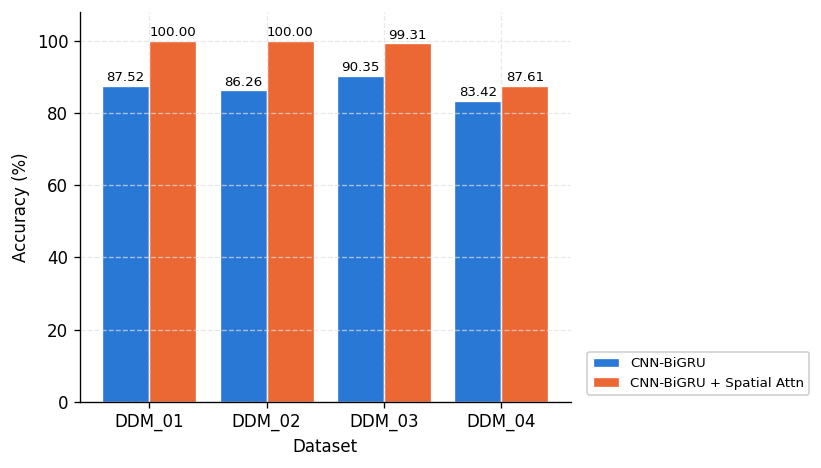

In [10]:
plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], curve='sgp4_norm', figsize=(8, 4))

# 1b. RQ2b: PER-FOLD OUTLIER-FILTER ABLATION (Ablation 6)

Reads `ablations/ablation6_chip_outlier_model_ablation_performances.joblib` per chip --
a separate 5-fold CV run (`ablation6_chip_outlier_model_ablation.py`, `ori_curve_sg_p4_norm`)
comparing 3 models x 3 outlier filters, distinct from RQ2's single-split `classification_performances.joblib` above.

In [11]:
ABL6_MODELS = ['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'gnn_gat']
ABL6_CURVE_TYPE = 'sgp4_norm'
ABL6_FILTERS = [None, 'amf_label_amf_send_5', f'lstm_ae_glb_ds{config.AE_DOWNSAMPLE_FACTOR}_label_elbow']
ABL6_FILTER_LABELS = {
    None: 'None',
    'amf_label_amf_send_5': 'AMF',
    f'lstm_ae_glb_ds{config.AE_DOWNSAMPLE_FACTOR}_label_elbow': 'LSTM-AE',
}

print(f"{len(ABL6_MODELS)} models x {len(ABL6_FILTERS)} filters defined.")

3 models x 3 filters defined.


In [12]:
def compute_fold_accuracy_stats(perf, model_key):
    """Mean/std accuracy ACROSS folds (not pooled) -- matches ablation6_chip_outlier_model_ablation.py's
    own '86.85% ± 0.49%' log line exactly (utils/model_training/model_utils.py:2476-2486):
    one accuracy_score() per fold, then np.mean/np.std (ddof=0) across those fold-level numbers."""
    pred_k = f'y_preds_AC_{model_key}_'
    if pred_k not in perf:
        return None
    fold_accs = [accuracy_score(yt, yp) for yt, yp in zip(perf['y_trues_'], perf[pred_k])]
    return {'accuracy_mean': np.mean(fold_accs) * 100, 'accuracy_std': np.std(fold_accs) * 100}


def load_ablation6_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        path = Path(PREP_DIRS['nc_subtract']) / folder / 'ablations' / 'ablation6_chip_outlier_model_ablation_performances.joblib'
        if not path.exists():
            print(f'[WARN] missing {path}')
            continue
        data = joblib.load(path)
        for filt in ABL6_FILTERS:
            perf = data.get(filt)
            if perf is None:
                continue
            for model in ABL6_MODELS:
                m = compute_metrics(perf, model)
                if m is None:
                    continue
                stats = compute_fold_accuracy_stats(perf, model)
                rows.append(dict(dataset=dataset, outlier_filter=filt, model=model,
                                 accuracy_mean=stats['accuracy_mean'], accuracy_std=stats['accuracy_std'], **m))
    return pd.DataFrame(rows)

abl6_df = load_ablation6_all()
print(f"Loaded {len(abl6_df)} rows  |  "
      f"{abl6_df.dataset.nunique()} datasets  "
      f"{abl6_df.outlier_filter.nunique(dropna=False)} filters  "
      f"{abl6_df.model.nunique()} models")
abl6_df.head(8)

Loaded 36 rows  |  4 datasets  3 filters  3 models


,dataset,outlier_filter,model,accuracy_mean,accuracy_std,accuracy,f1,auc,sensitivity,specificity
0,DDM_01,None,cnn_gru_dual,86.854646,0.485546,0.868546,0.839531,0.978432,0.836086,0.972853
1,DDM_01,None,cnn_gru_dual_attn_recon,99.276257,0.428136,0.992762,0.991128,0.999812,0.991151,0.998587
2,DDM_01,None,gnn_gat,98.642076,0.612416,0.986420,0.982710,0.998973,0.982846,0.997284
3,DDM_01,amf_label_amf_send_5,cnn_gru_dual,87.881695,0.334778,0.878817,0.855252,0.981602,0.851930,0.975210
4,DDM_01,amf_label_amf_send_5,cnn_gru_dual_attn_recon,99.352518,0.205981,0.993525,0.992148,0.999875,0.992023,0.998730
5,DDM_01,amf_label_amf_send_5,gnn_gat,98.848921,0.376973,0.988489,0.985839,0.999495,0.985721,0.997756
6,DDM_01,lstm_ae_glb_ds1_label_elbow,cnn_gru_dual,87.396356,0.721416,0.873963,0.847424,0.980207,0.843786,0.973920
7,DDM_01,lstm_ae_glb_ds1_label_elbow,cnn_gru_dual_attn_recon,99.468010,0.327441,0.994680,0.993466,0.999921,0.993307,0.998942


In [13]:
abl6_expected = len(ABL6_MODELS) * len(ABL6_FILTERS)
abl6_check = (abl6_df.groupby('dataset')
                .size()
                .reset_index(name='n')
                .assign(expected=abl6_expected, ok=lambda x: x.n == x.expected))
abl6_missing = abl6_check[~abl6_check.ok]
if abl6_missing.empty:
    print("All (model, filter) combinations fully populated.")
else:
    print("[!] Incomplete combinations (job likely still running):")
    display(abl6_missing)

All (model, filter) combinations fully populated.


In [14]:
import colorsys
from matplotlib.colors import to_rgb


def _shade(base_rgb, frac, spread=0.6):
    """frac=1 -> lighter, frac=0 -> darker, frac=0.5 -> unchanged. Same recipe as
    0_LOFO_INSPECTION.ipynb's _shade (used there for concentration shading)."""
    h, l, s = colorsys.rgb_to_hls(*base_rgb[:3])
    l = min(0.85, max(0.15, l + (frac - 0.5) * spread))
    return colorsys.hls_to_rgb(h, l, s)


def plot_accuracy_by_model_filter(df, models, filters, filter_labels, figsize=(16, 5.5)):
    """Grouped bar chart: x=dataset, one sub-bar per (model, filter) pair. Color=model
    (same PALETTE indexing as plot_accuracy_by_model above), shade=filter (lighter=None,
    darker=more filtering). Error bars = std across the 5 CV folds; label = mean ± std."""
    datasets = DATASET_NAMES
    n_bars = len(models) * len(filters)
    bar_w = 0.8 / n_bars
    x = np.arange(len(datasets))

    fig, ax = plt.subplots(figsize=figsize)
    bi = 0
    for mi, model in enumerate(models):
        base_rgb = to_rgb(PALETTE[mi % len(PALETTE)])
        for fi, filt in enumerate(filters):
            frac = 1 - fi / (len(filters) - 1) if len(filters) > 1 else 0.5
            color = _shade(base_rgb, frac)
            filt_mask = df.outlier_filter.isna() if filt is None else (df.outlier_filter == filt)
            sub = df[(df.model == model) & filt_mask]
            ys, errs = [], []
            for ds in datasets:
                r = sub[sub.dataset == ds]
                if r.empty:
                    ys.append(np.nan); errs.append(np.nan)
                else:
                    ys.append(r['accuracy_mean'].iloc[0]); errs.append(r['accuracy_std'].iloc[0])
            ys, errs = np.array(ys), np.array(errs)

            offset = (bi - (n_bars - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), yerr=np.nan_to_num(errs, nan=0),
                  width=bar_w, color=color, edgecolor='white', linewidth=0.5,
                  capsize=2, error_kw=dict(elinewidth=0.7, ecolor='#3a3a3a'))
            for xi, yi, ei in zip(x + offset, ys, errs):
                if not np.isnan(yi):
                    ax.text(xi, yi + ei + 0.5, f'{yi:.1f}±{ei:.1f}', ha='center', va='bottom',
                           fontsize=5.5, rotation=90)
            bi += 1

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 120)

    model_handles = [plt.Line2D([0], [0], marker='s', color='w', markersize=11,
                                markerfacecolor=PALETTE[mi % len(PALETTE)], label=FAMILY_LABELS.get(m, m))
                     for mi, m in enumerate(models)]
    filter_handles = [plt.Line2D([0], [0], marker='s', color='w', markersize=11,
                                 markerfacecolor=_shade((0.5, 0.5, 0.5),
                                                        1 - fi / (len(filters) - 1) if len(filters) > 1 else 0.5),
                                 label=filter_labels[filt])
                      for fi, filt in enumerate(filters)]
    ax.legend(handles=model_handles + filter_handles, fontsize=8, ncol=2,
             loc='upper center', bbox_to_anchor=(0.5, -0.12), framealpha=0.9)
    fig.tight_layout()
    plt.show()

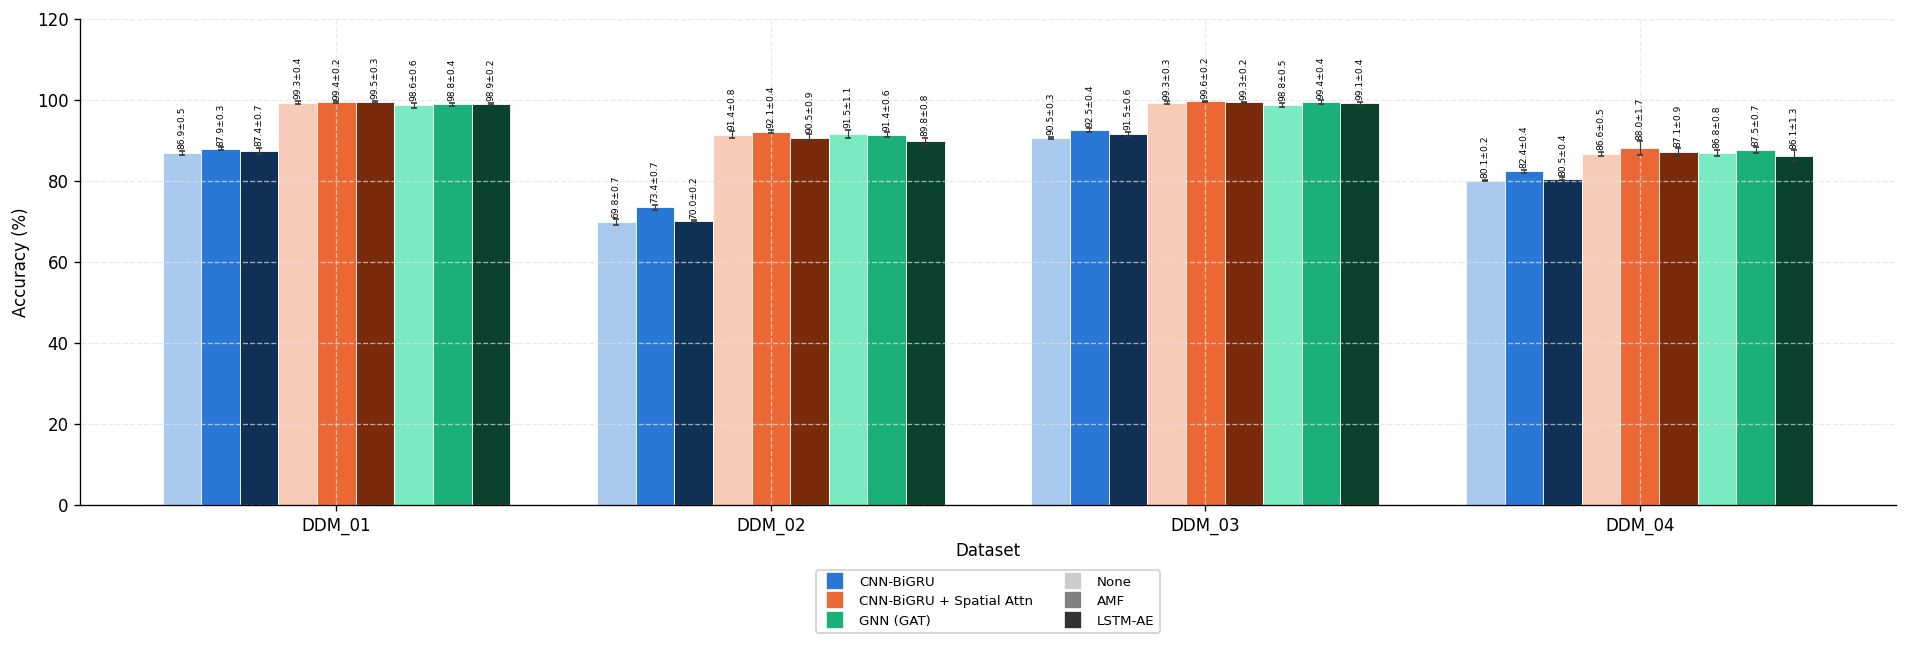

In [15]:
plot_accuracy_by_model_filter(abl6_df, ABL6_MODELS, ABL6_FILTERS, ABL6_FILTER_LABELS)

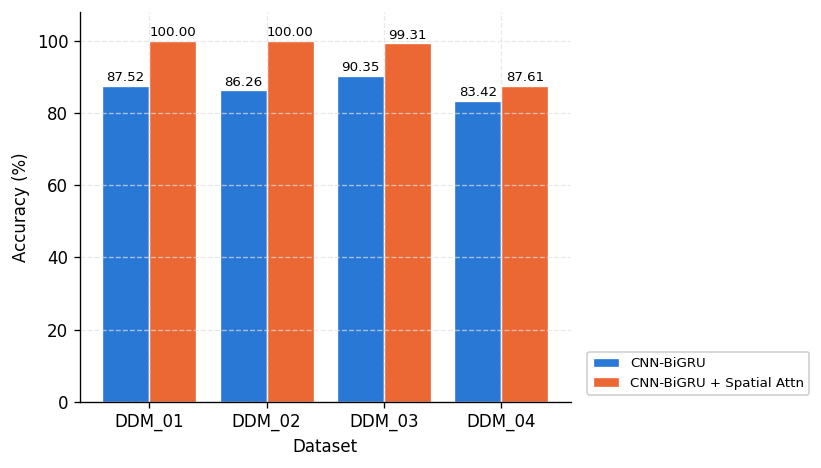

In [16]:
plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], curve='sgp4_norm', figsize=(8, 4))

In [17]:
abl6_df[abl6_df["outlier_filter"].isnull()].head()

,dataset,outlier_filter,model,accuracy_mean,accuracy_std,accuracy,f1,auc,sensitivity,specificity
0,DDM_01,None,cnn_gru_dual,86.854646,0.485546,0.868546,0.839531,0.978432,0.836086,0.972853
1,DDM_01,None,cnn_gru_dual_attn_recon,99.276257,0.428136,0.992762,0.991128,0.999812,0.991151,0.998587
2,DDM_01,None,gnn_gat,98.642076,0.612416,0.986420,0.982710,0.998973,0.982846,0.997284
9,DDM_02,None,cnn_gru_dual,69.785992,0.716418,0.697860,0.623777,0.913510,0.626102,0.938721
10,DDM_02,None,cnn_gru_dual_attn_recon,91.374838,0.828214,0.913748,0.885955,0.989313,0.886265,0.983375


In [18]:
df.head()

,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.930393,0.913073,0.992633,0.912648,0.986108
1,DDM_01,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
2,DDM_01,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.940209,0.924441,0.996013,0.920385,0.984448
3,DDM_01,nc_subtract,ori_norm,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
4,DDM_01,nc_subtract,sgp4_norm,cnn_gru_dual,cnn_gru_dual,0,0.875187,0.837181,0.976595,0.834549,0.968748


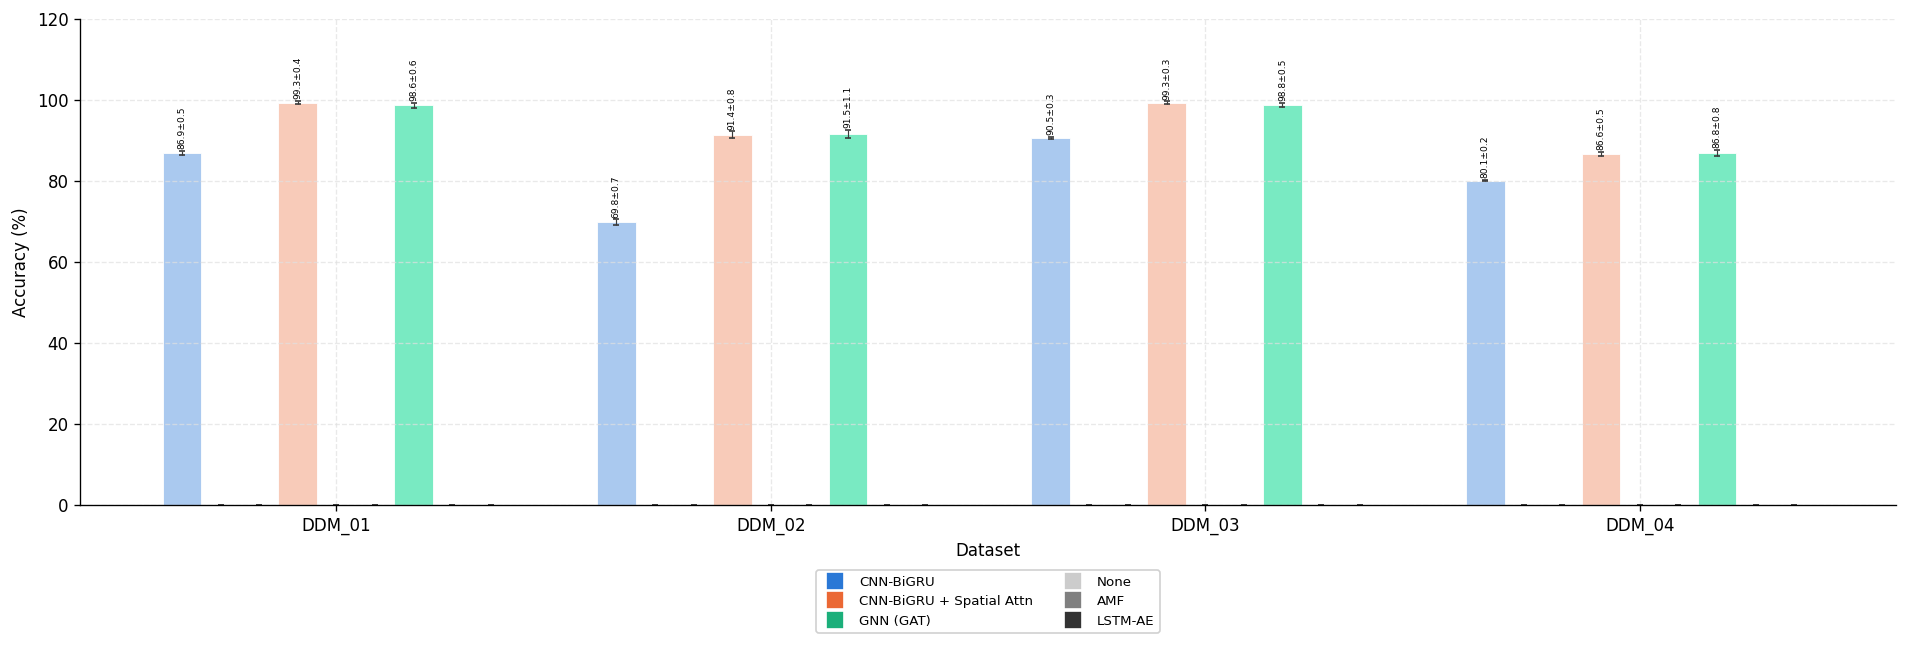

In [19]:
plot_accuracy_by_model_filter(abl6_df[abl6_df["outlier_filter"].isnull()], ABL6_MODELS, ABL6_FILTERS, ABL6_FILTER_LABELS)

# 2. RQ3.1: CROSS VALIDATION

In [20]:
import importlib

# Reuse 06b's own results-file discovery instead of reimplementing it, so this
# section always matches what 06b_cross_dataset_prediction_report.py actually reads.
b06 = importlib.import_module("06b_cross_dataset_prediction_report")

CV_EXP_FOLDER  = PREP_DIRS['nc_subtract']
CV_MODE_STR    = "kfold5"
CV_FILTER      = "noamp_remove"
CV_CURVE_TYPES = ["ori_curve_norm", "ori_curve_sg_p4_norm"]
CV_CURVE_SHORT = {"ori_curve_norm": "ori_norm", "ori_curve_sg_p4_norm": "sgp4_norm"}

def cv_group_dir(group_name):
    return Path(CV_EXP_FOLDER) / "cross_dataset_cv" / group_name

def load_cv_results(group_name, curve_type):
    group_dir = cv_group_dir(group_name)
    print(group_dir)
    legacy_path = b06.find_results_path(group_dir, CV_MODE_STR, curve_type)
    print(legacy_path)
    return b06.load_partitioned(group_dir, CV_MODE_STR, curve_type, legacy_path=legacy_path)

In [21]:
CV_MODELS = MODELS + ['gnn_gat']

def load_cv_accuracy(group_indices=None):
    if group_indices is not None:
        groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
    else:
        groups = list(config.CROSS_DATASET_GROUPS)

    rows = []
    for group_name in groups:
        for curve_type in CV_CURVE_TYPES:
            lofo_results = load_cv_results(group_name, curve_type)
            if not lofo_results:
                print(f"[WARN] No results for group {group_name} / curve {curve_type}")
                continue
            fold_labels = sorted([k for k in lofo_results if k.startswith("fold_")],
                                  key=lambda s: int(s.split("_")[1]))
            for fold in fold_labels:
                res_entry = lofo_results[fold].get(CV_FILTER)
                if res_entry is None:
                    continue
                for model in CV_MODELS:
                    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                    if preds_key is None or preds_key not in res_entry:
                        continue
                    y_true = np.concatenate(res_entry["y_trues_"])
                    y_pred = np.concatenate(res_entry[preds_key])
                    rows.append(dict(group=group_name, curve_type=CV_CURVE_SHORT.get(curve_type, curve_type),
                                     fold=fold, model=model, family=MODEL_TO_FAMILY.get(model, model),
                                     accuracy=accuracy_score(y_true, y_pred) * 100,
                                     n_test=len(y_true)))
    return pd.DataFrame(rows)

cv_df = load_cv_accuracy(group_indices=[3, 4, 5])
if cv_df.empty:
    print("Loaded 0 rows -- no kfold5 CV results found for the requested groups/curve types.")
else:
    print(f"Loaded {len(cv_df)} rows  |  "
          f"{cv_df.group.nunique()} groups  "
          f"{cv_df.curve_type.nunique()} curve types  "
          f"{cv_df.fold.nunique()} folds  "
          f"{cv_df.model.nunique()} models")
cv_df.head(8)


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean_nn
None
[WARN] No results for group final_4_chip_clean_nn / curve ori_curve_norm
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean_nn
None
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_cleanv2_nn
None
[WARN] No results for group final_4_chip_cleanv2_nn / curve ori_curve_norm
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_cleanv2_nn
None
[WARN] No results for group final_4_chip_cleanv2_nn / curve ori_curve_sg_p4_norm
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_cov_hadv_iav
None
[WARN] No results for group final_4_chip_cov_hadv_iav / curve ori_curve_norm
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_cov_hadv_iav
None
[WARN] No results for group final_

,group,curve_type,fold,model,family,accuracy,n_test
0,final_4_chip_clean_nn,sgp4_norm,fold_0,cnn_gru_dual,cnn_gru_dual,80.349482,9557
1,final_4_chip_clean_nn,sgp4_norm,fold_0,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,96.683060,9557
2,final_4_chip_clean_nn,sgp4_norm,fold_1,cnn_gru_dual,cnn_gru_dual,81.191552,9517
3,final_4_chip_clean_nn,sgp4_norm,fold_1,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,96.122728,9517
4,final_4_chip_clean_nn,sgp4_norm,fold_1,gnn_gat,gnn_gat,94.819796,9517
5,final_4_chip_clean_nn,sgp4_norm,fold_2,cnn_gru_dual,cnn_gru_dual,84.215481,9560
6,final_4_chip_clean_nn,sgp4_norm,fold_2,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,96.087866,9560
7,final_4_chip_clean_nn,sgp4_norm,fold_2,gnn_gat,gnn_gat,95.167364,9560


In [22]:
cv_expected = len(CV_MODELS)
cv_check = (cv_df.groupby(['group', 'curve_type', 'fold'])
              .size()
              .reset_index(name='n')
              .assign(expected=cv_expected, ok=lambda x: x.n == x.expected))
cv_missing = cv_check[~cv_check.ok]
if cv_missing.empty:
    print("All CV combinations fully populated.")
else:
    print("[!] Incomplete CV combinations (job likely still running):")
    display(cv_missing)


[!] Incomplete CV combinations (job likely still running):


,group,curve_type,fold,n,expected,ok
0,final_4_chip_clean_nn,sgp4_norm,fold_0,2,3,False


In [23]:
def plot_grouped_bar_by_model(df, x_col, x_order, models, model_labels,
                               value_col='accuracy', xlabel='', title='', figsize=(10, 6), plot_fold=True, plot_summary=True, show_std=True):

    n_models = len(models)

    if plot_fold:
        bar_w = 0.8 / n_models
        x = np.arange(len(x_order))

        fig, ax = plt.subplots(figsize=figsize)
        for mi, model in enumerate(models):
            sub = df[df.model == model].set_index(x_col)[value_col]
            ys = np.array([sub.get(v, np.nan) for v in x_order])
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                color=PALETTE[mi % len(PALETTE)],
                label=model_labels.get(model, model),
                edgecolor='white', linewidth=0.8)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Accuracy (%)')
        ax.set_ylim(0, 108)
        ax.legend(title='Model', fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
        ax.set_title(title, fontsize=11, fontweight='bold')
        fig.tight_layout()
        plt.show()

    stats = df.groupby('model')[value_col].agg(['mean', 'std']).reindex(models)
    
    if plot_summary:
        mean_v = stats['mean'].to_numpy()
        std_v  = np.nan_to_num(stats['std'].to_numpy(), nan=0)
        x2 = np.arange(n_models)

        fig2, ax2 = plt.subplots(figsize=(0.75 * n_models + 2, 6))
        if show_std:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0), yerr=std_v, capsize=4,
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8,
                error_kw=dict(ecolor='#3a3a3a', elinewidth=1.2))
        else:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0),
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8)
        for xi, mv, sv in zip(x2, mean_v, std_v):
            if np.isnan(mv):
                continue
            # ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} ± {sv:.2f}', ha='center', va='bottom', fontsize=12)
            if show_std:
                ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} ± {sv:.2f}', ha='center', va='bottom', fontsize=11)
            else:
                ax2.text(xi, mv + 0.5, f'{mv:.2f}', ha='center', va='bottom', fontsize=11)

        ax2.set_xticks(x2)
        ax2.set_xticklabels([model_labels.get(m, m) for m in models], fontsize=9, rotation=30, ha='right')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_ylim(0, 108)
        ax2.set_title(f'{title}\nMean ± std across {len(x_order)} {xlabel.lower()}s',
                    fontsize=11, fontweight='bold')
        fig2.tight_layout()
        plt.show()
    return stats


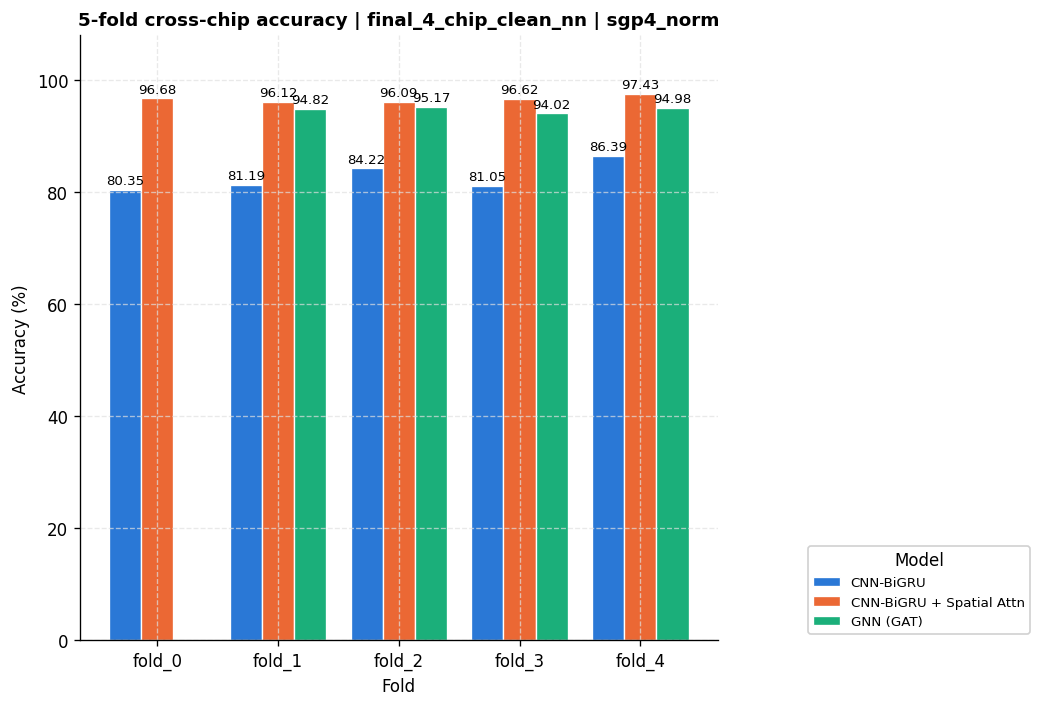

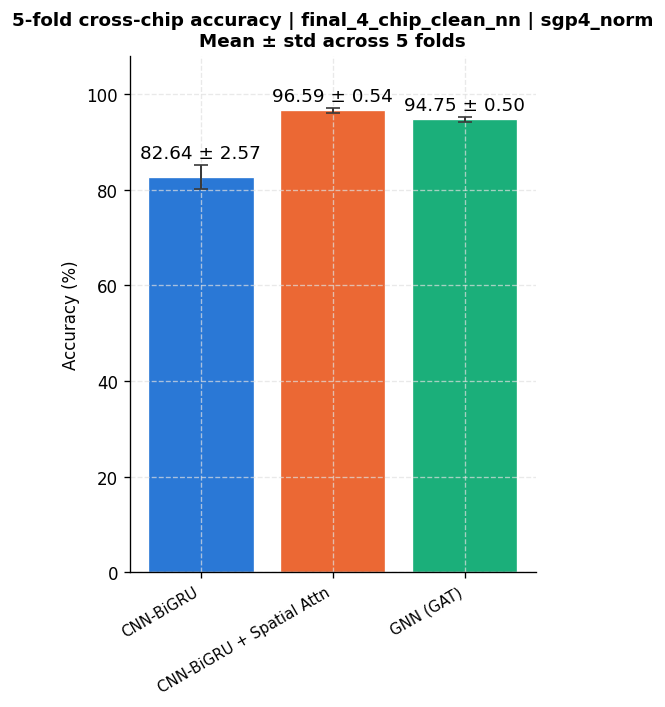


Mean ± std across folds (final_4_chip_clean_nn | sgp4_norm):
                          mean   std
model                               
cnn_gru_dual             82.64  2.57
cnn_gru_dual_attn_recon  96.59  0.54
gnn_gat                  94.75  0.50


In [24]:
%matplotlib inline

for (group_name, curve_type), sub in cv_df.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique(), key=lambda s: int(s.split('_')[1]))
    stats = plot_grouped_bar_by_model(
        sub, x_col='fold', x_order=fold_labels, models=CV_MODELS, model_labels=FAMILY_LABELS,
        xlabel='Fold', title=f'5-fold cross-chip accuracy | {group_name} | {curve_type}',
    )
    print(f"\nMean ± std across folds ({group_name} | {curve_type}):")
    print(stats.round(2))


# 3. RQ3.2: LOFO

In [25]:
p08   = importlib.import_module("08_cross_dataset_predict_new_chip")
vis07 = importlib.import_module("07_attribution_vis_all")
rio   = importlib.import_module("cross_dataset_result_io")

import tensorflow as tf
tf.config.optimizer.set_jit(False)

LOFO_MODE_STR      = "lofo"
LOFO_CURVE_ALIGN   = "pc_ttp"
LOFO_PC_TTP_ANCHOR = "min"
LOFO_FRAC          = None
LOFO_FILTER        = "noamp_remove"
# LOFO_CURVE_TYPES   = ["ori_curve_norm", "ori_curve_wavelet_bior35_norm"]
# LOFO_CURVE_SHORT   = {"ori_curve_norm": "ori_norm", "ori_curve_wavelet_bior35_norm": "bior35_norm"}
LOFO_CURVE_TYPES = ["ori_curve_norm", "ori_curve_sg_p4_norm"]
LOFO_CURVE_SHORT = {"ori_curve_norm": "ori_norm", "ori_curve_sg_p4_norm": "sgp4_norm"}

COMPARISON_1 = ["cnn_gru_dual", "cnn_gru_dual_supcon3", "cnn_gru_dual_dann", "cnn_gru_dual_coral"]
COMPARISON_2 = ["cnn_gru_dual_attn_recon", "cnn_gru_dual_attn_recon_supcon3",
                "cnn_gru_dual_attn_recon_dann", "cnn_gru_dual_attn_recon_coral"]
COMPARISON_3 = ["gnn_gat", "gnn_gat_supcon3", "gnn_gat_dann", "gnn_gat_coral"]
LOFO_COMPARISON_1 = COMPARISON_1 + ["cnn_gru_dual_pc_recenter"]
LOFO_COMPARISON_2 = COMPARISON_2 + ["cnn_gru_dual_attn_recon_pc_recenter"]
LOFO_COMPARISON_3 = COMPARISON_3  # no pc_recenter variant for gnn_gat yet -- see load_lofo_accuracy

def lofo_group_dir(group_name):
    return b06.alignment_dir(cv_group_dir(group_name), LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR)

def load_lofo_results(group_name, curve_type):
    out_dir = lofo_group_dir(group_name)
    legacy_path = b06.find_results_path(out_dir, LOFO_MODE_STR, curve_type)
    return b06.load_partitioned(out_dir, LOFO_MODE_STR, curve_type, legacy_path=legacy_path)

In [26]:
LOFO_CURVE_TYPES

['ori_curve_norm', 'ori_curve_sg_p4_norm']

In [27]:
PC_RECENTER_CACHE_NAME = "pc_recenter_sweep_cache.joblib"

def _pc_cache_path(group_name):
    return Path(CV_EXP_FOLDER) / "cross_dataset_cv" / group_name / PC_RECENTER_CACHE_NAME

def load_pc_cache(group_name):
    path = _pc_cache_path(group_name)
    if not path.exists():
        return {}
    try:
        return joblib.load(path)
    except Exception:
        return {}

def save_pc_cache(group_name, cache):
    path = _pc_cache_path(group_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(cache, path, compress=3)

def _mtime(path):
    try:
        return path.stat().st_mtime
    except FileNotFoundError:
        return None

def pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=None):
    align_dir = config.cross_dataset_alignment_dir(out_dir, held_out_chip)
    return (_mtime(model_path),
           _mtime(align_dir / config.CROSS_DATASET_RESAMPLER_PATH.format(curve_type=curve_type)),
           _mtime(align_dir / config.CROSS_DATASET_PC_TTP_RECIPE_PATH.format(curve_type=curve_type)))


In [28]:
def lofo_ground_truth(chip_name, Y_well_raw, class_names):
    mapping = config.LABEL_MAPPINGS[chip_name]
    y_true = np.array([mapping.get(w, w) for w in Y_well_raw])
    if class_names:
        cn = list(class_names)
        y_true = np.array([next((c for c in cn if y == c or y.startswith(c + '-') or c.startswith(y + '-')), y)
                           for y in y_true])
    return y_true


def lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path, exp_paths_all, class_names, cache):
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    fold_label = f"lofo_{chip_name}"
    model_dir = out_dir / "model_interpretation" / fold_label
    model_path = model_dir / f"{base_model}_{LOFO_FILTER}_{curve_type}{rio.frac_suffix(LOFO_FRAC)}_model.keras"
    if not model_path.exists():
        return None

    cache_key = (curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR, LOFO_FRAC, LOFO_FILTER, base_model, chip_name)
    sig = pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=chip_name)
    cached = cache.get(cache_key)
    if cached is not None and cached["sig"] == sig:
        return cached["row"]

    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result

    loaded = vis07.load_saved_models(model_dir, LOFO_FILTER, len(resampler.t_grid), curve_type=curve_type,
                                     model_names=[base_model], train_center_frac=LOFO_FRAC)
    if base_model not in loaded:
        return None
    model = loaded[base_model]
    if p08._is_spatial(base_model) and (coords is None or well_ids is None):
        return None

    y_true = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    valid = y_true != "PC"
    exp_paths_train = [p for p in exp_paths_all if p.name != chip_name]

    probs_base, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                         exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                         pc_recenter=False, held_out_chip=chip_name)
    pred_base = np.array(class_names)[np.argmax(probs_base, axis=1)]
    acc_base = (pred_base[valid] == y_true[valid]).mean() if valid.any() else float('nan')

    acc_recenter = float('nan')
    try:
        probs_r, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                          exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                          pc_recenter=True, force_rerun=True, held_out_chip=chip_name)
        pred_r = np.array(class_names)[np.argmax(probs_r, axis=1)]
        acc_recenter = (pred_r[valid] == y_true[valid]).mean() if valid.any() else float('nan')
    except ValueError:
        pass   # no PC snapshot for this chip -- leave acc_recenter as NaN

    row = {"acc_baseline": acc_base * 100, "acc_pc_recenter": acc_recenter * 100, "n_pixels": int(valid.sum())}
    cache[cache_key] = {"sig": sig, "row": row}
    save_pc_cache(group_name, cache)

    del model, loaded
    tf.keras.backend.clear_session()
    return row


In [29]:
def load_lofo_accuracy(groups=None, group_indices=None):
    if groups is None:
        if group_indices is not None:
            groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
        else:
            groups = list(config.CROSS_DATASET_GROUPS)
    all_models = COMPARISON_1 + COMPARISON_2 + COMPARISON_3
    rows = []
    for group_name in groups:
        exp_paths_all = [Path(CV_EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
        pc_cache = None

        for curve_type in LOFO_CURVE_TYPES:
            lofo_results = load_lofo_results(group_name, curve_type)
            if not any(k != "full_data" for k in lofo_results):
                continue
            if pc_cache is None:
                pc_cache = load_pc_cache(group_name)

            for chip_path in exp_paths_all:
                fold_entry = lofo_results.get(f"lofo_{chip_path.name}", {})
                res_entry = fold_entry.get(LOFO_FILTER)
                class_names = fold_entry.get("class_names")
                fold = short_name(chip_path.name)

                if res_entry is not None:
                    for model in all_models:
                        preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                        if preds_key is None or preds_key not in res_entry:
                            continue
                        y_true = np.concatenate(res_entry["y_trues_"])
                        y_pred = np.concatenate(res_entry[preds_key])
                        rows.append(dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                         fold=fold, model=model,
                                         accuracy=accuracy_score(y_true, y_pred) * 100, n_test=len(y_true)))

                if class_names is None:
                    continue
                for base_model in ("cnn_gru_dual", "cnn_gru_dual_attn_recon"):
                    result = lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path,
                                                       exp_paths_all, class_names, pc_cache)
                    if result is None:
                        continue
                    rows.append(dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                     fold=fold, model=f"{base_model}_pc_recenter",
                                     accuracy=result["acc_pc_recenter"], n_test=result["n_pixels"]))
    return pd.DataFrame(rows)

lofo_df = load_lofo_accuracy(group_indices=[3, 4, 5])
print(f"Loaded {len(lofo_df)} rows  |  "
      f"{lofo_df.group.nunique()} groups  "
      f"{lofo_df.curve_type.nunique()} curve types  "
      f"{lofo_df.fold.nunique()} folds  "
      f"{lofo_df.model.nunique()} models")
lofo_df.head(8)


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [PC-TTP align] new chip TTP=333.33  anchor=91.83  shift=241.51


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 58 variables whereas the saved optimizer has 54 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 54 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  [*] Saved PC reference embedding -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean_nn/curve_alignment_pc_ttp/anchor_min/model_interpretation/lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06/pc_reference_embedding_cnn_gru_dual_noamp_remove_ori_curve_sg_p4_norm.joblib
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [PC-TTP align] new chip TTP=333.33  anchor=91.83  shift=241.51
  [*] Saved PC reference embedding -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean_nn/curve_alignment_pc_ttp/anchor_min/model_interpretation/lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06/pc_reference_embedding_cnn_gru_dual_attn_recon_noamp_remove_ori_curve_sg_p4_norm.joblib
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 5523 sa

,group,curve_type,fold,model,accuracy,n_test
0,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual,34.190290,13264
1,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_supcon3,32.765380,13264
2,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_dann,36.293727,13264
3,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_coral,34.838661,13264
4,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon,24.170688,13264
5,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon_supcon3,31.951146,13264
6,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon_dann,25.128166,13264
7,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon_coral,12.002413,13264


In [30]:
def lofo_completeness(df, comparison_models, label):
    check = (df[df.model.isin(comparison_models)]
               .groupby(['group', 'curve_type', 'fold'])
               .size()
               .reset_index(name='n')
               .assign(expected=len(comparison_models), ok=lambda x: x.n == x.expected))
    missing = check[~check.ok]
    if missing.empty:
        print(f"[{label}] All combinations fully populated.")
    else:
        print(f"[{label}] Incomplete combinations:")
        display(missing)

lofo_completeness(lofo_df, LOFO_COMPARISON_1, "Comparison 1 (cnn_gru_dual family)")
lofo_completeness(lofo_df, LOFO_COMPARISON_2, "Comparison 2 (cnn_gru_dual_attn_recon family)")
lofo_completeness(lofo_df, LOFO_COMPARISON_3, "Comparison 3 (gnn_gat family)")


[Comparison 1 (cnn_gru_dual family)] Incomplete combinations:


,group,curve_type,fold,n,expected,ok
1,final_4_chip_clean_nn,ori_norm,DDM_02,1,5,False
6,final_4_chip_cleanv2_nn,ori_norm,DDM_01,3,5,False


[Comparison 2 (cnn_gru_dual_attn_recon family)] Incomplete combinations:


,group,curve_type,fold,n,expected,ok
5,final_4_chip_cleanv2_nn,ori_norm,DDM_01,3,5,False


[Comparison 3 (gnn_gat family)] All combinations fully populated.


In [31]:
lofo_df.group.unique()

array(['final_4_chip_clean_nn', 'final_4_chip_cleanv2_nn',
       'final_4_chip_cov_hadv_iav'], dtype=object)

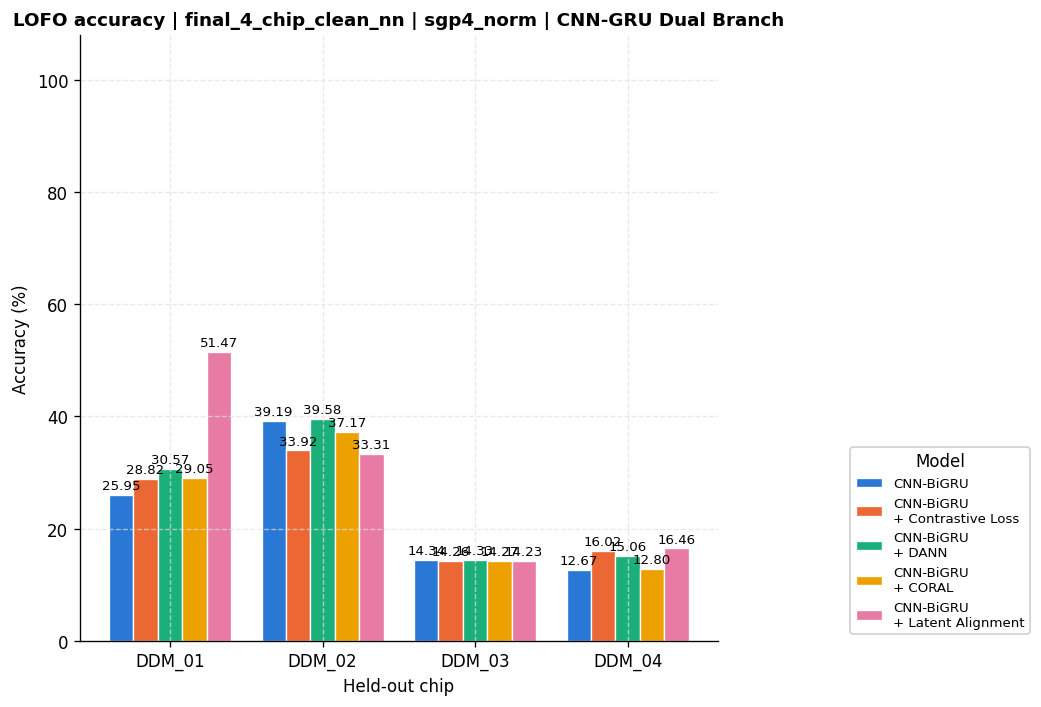

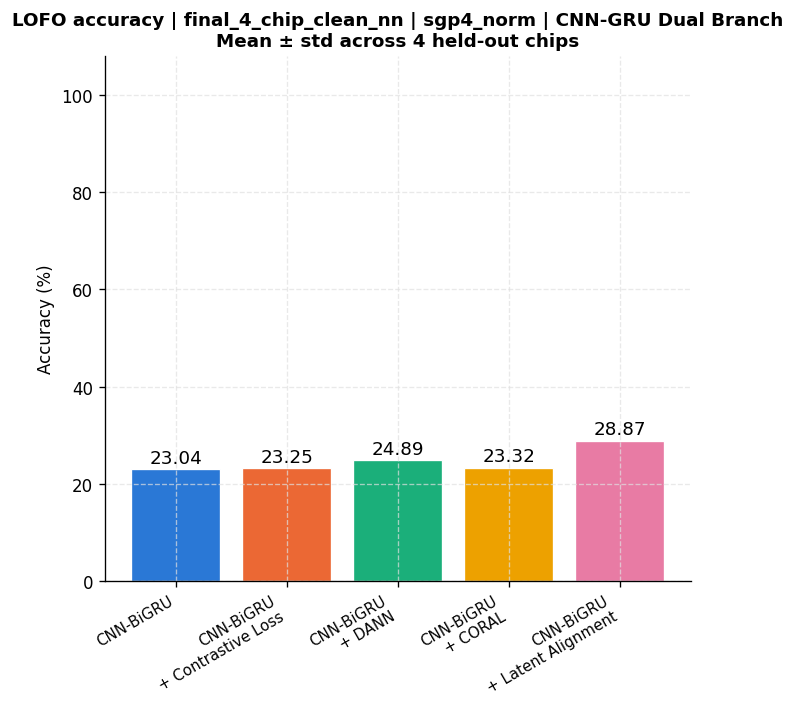

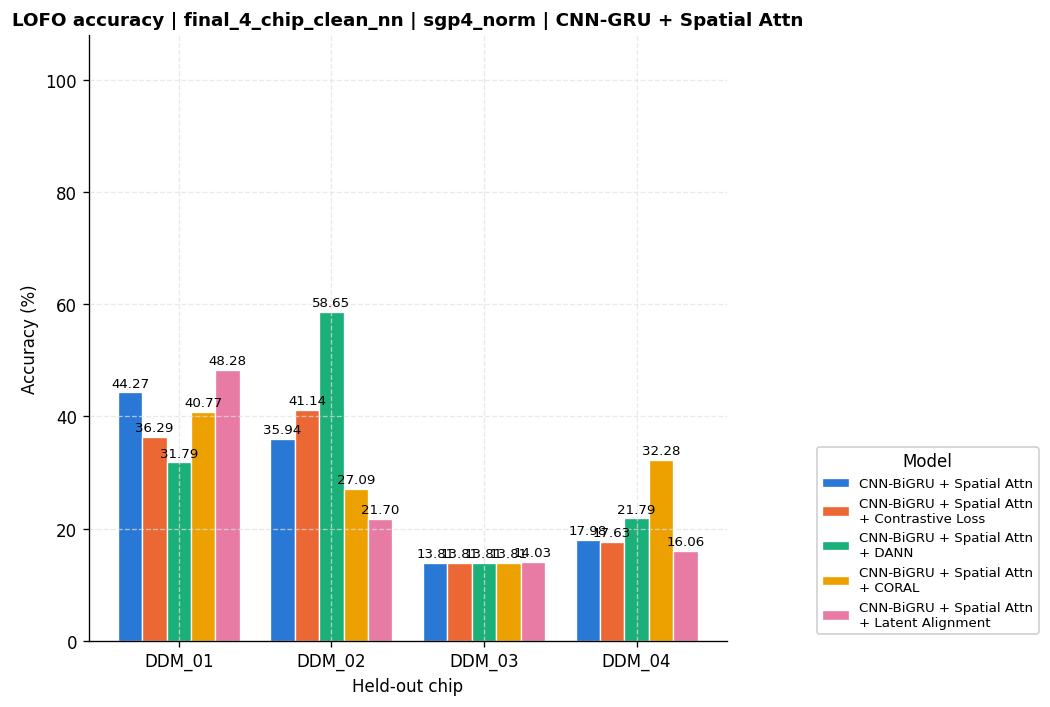

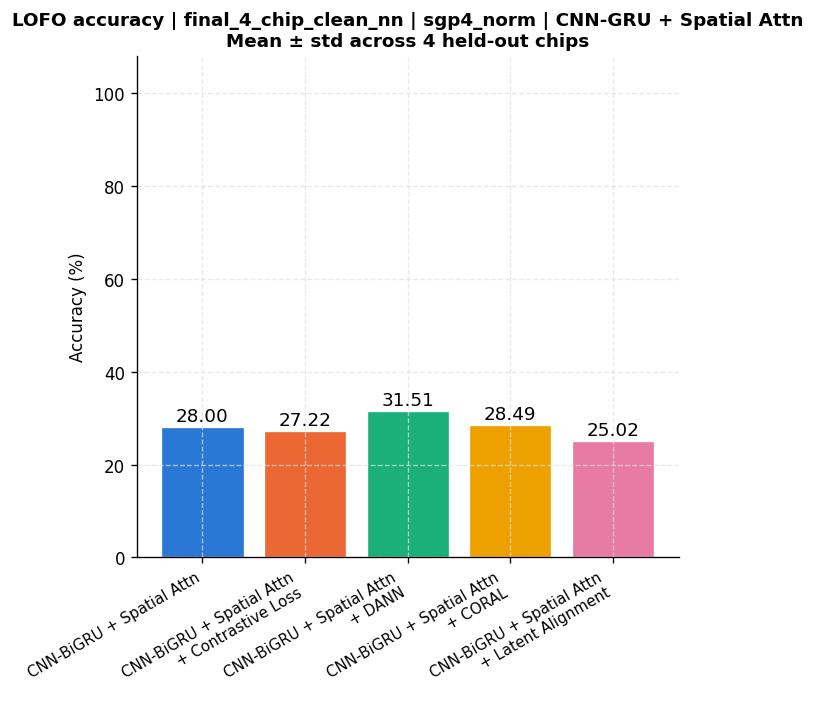

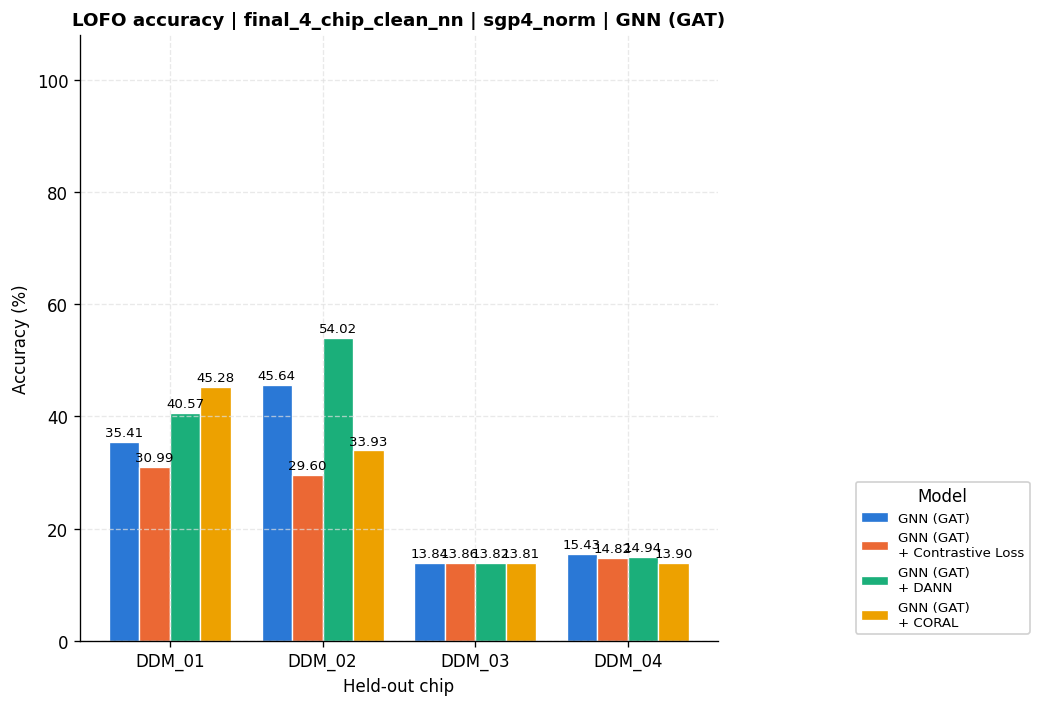

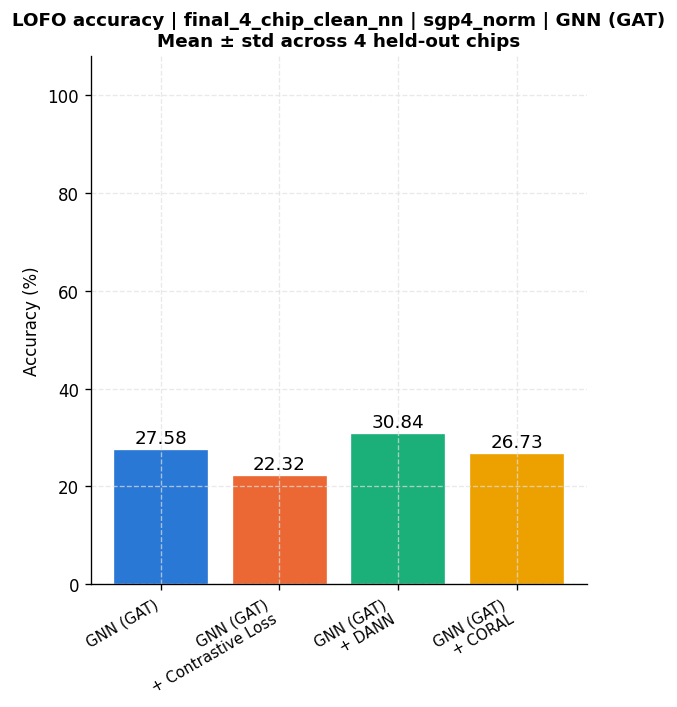

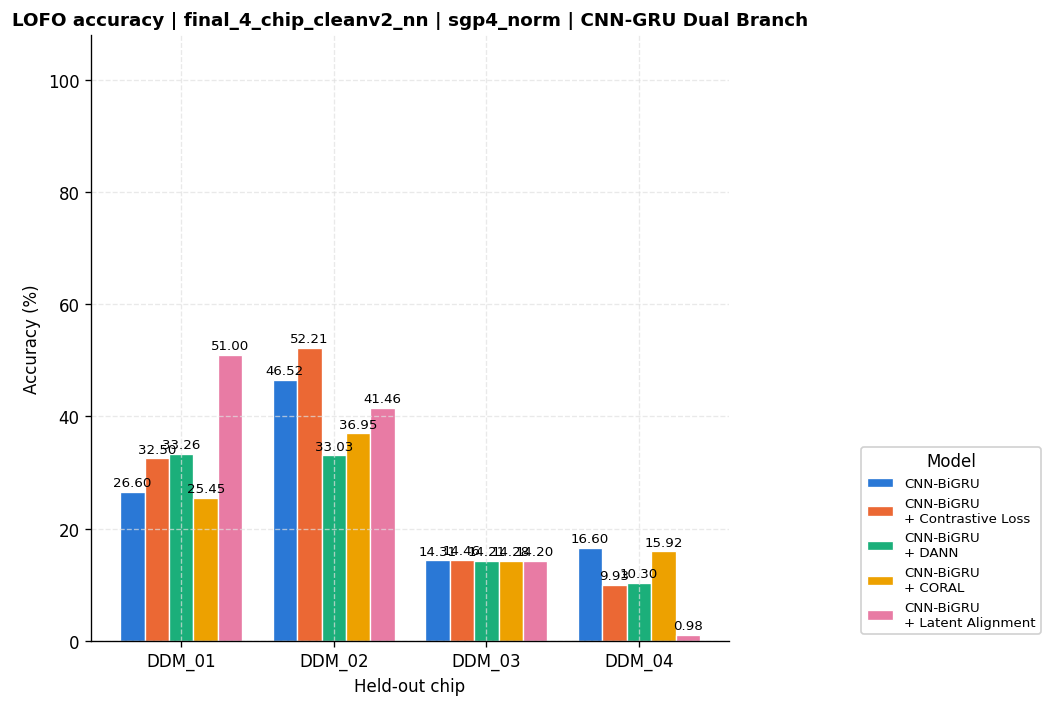

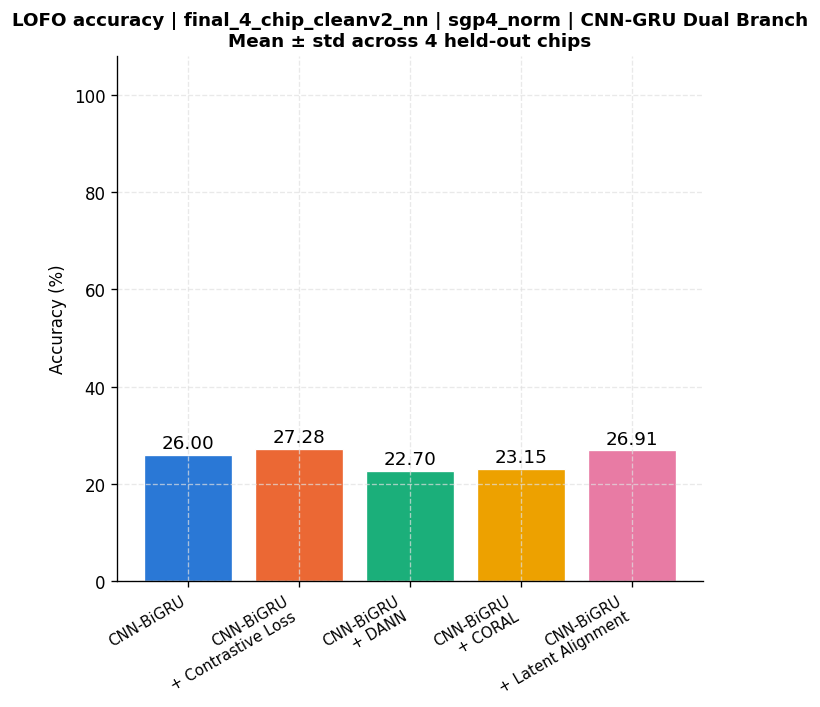

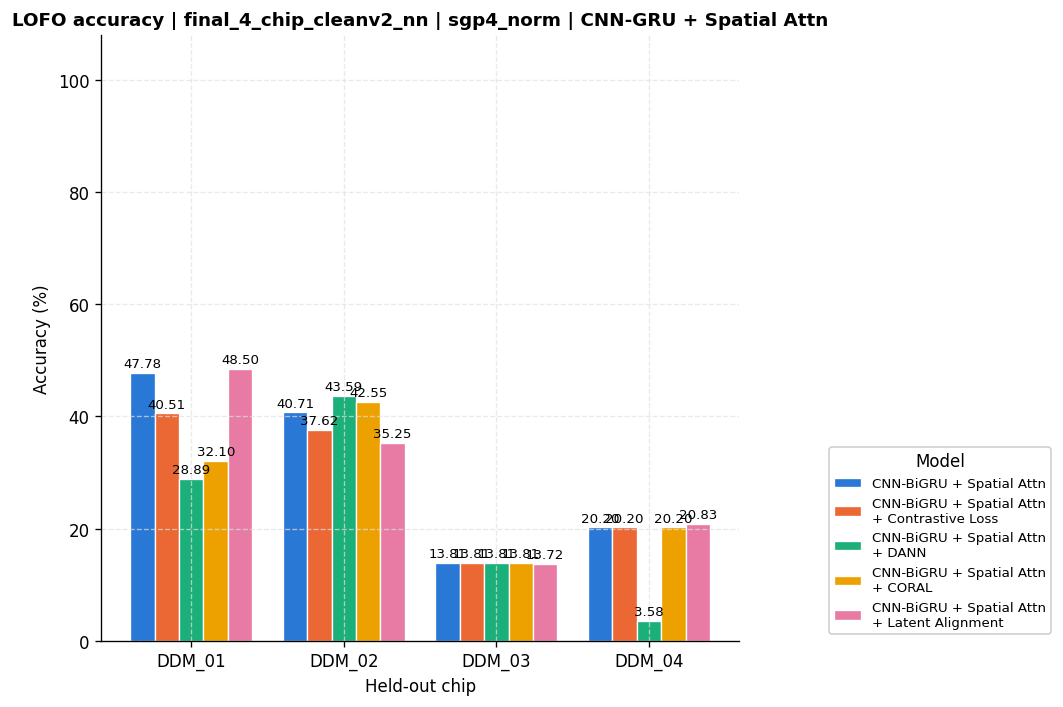

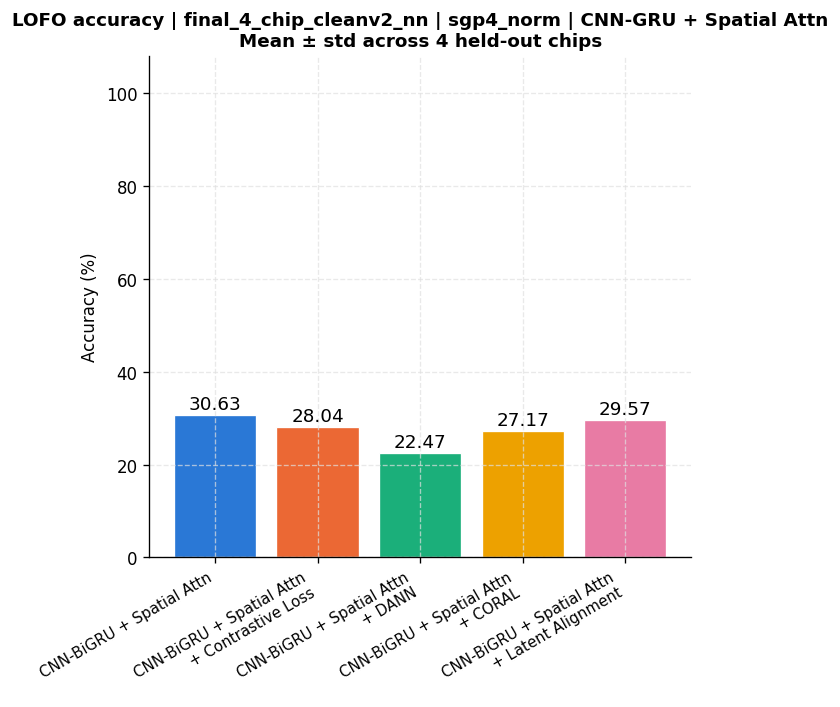

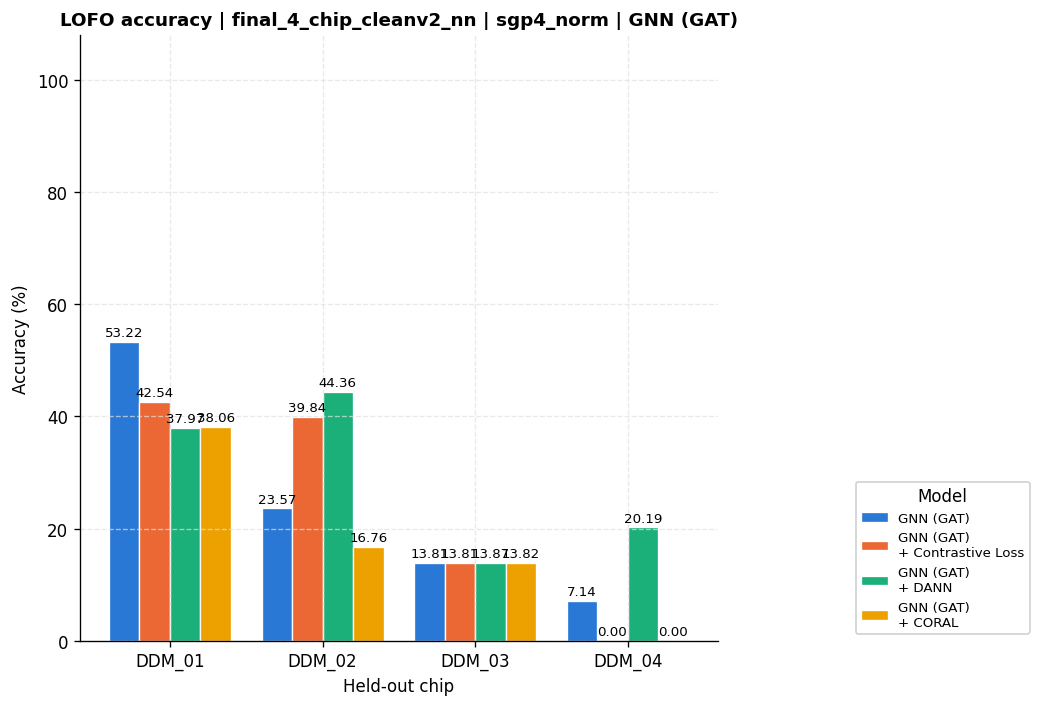

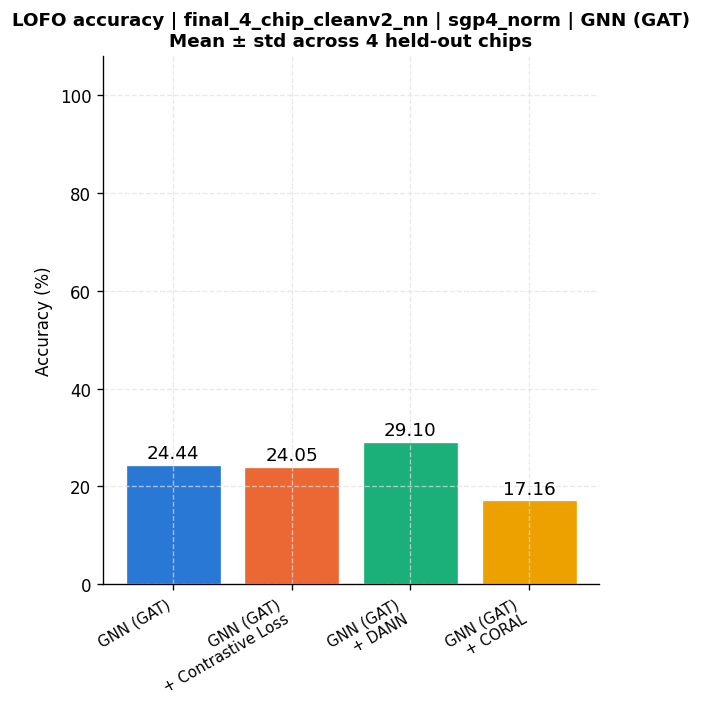

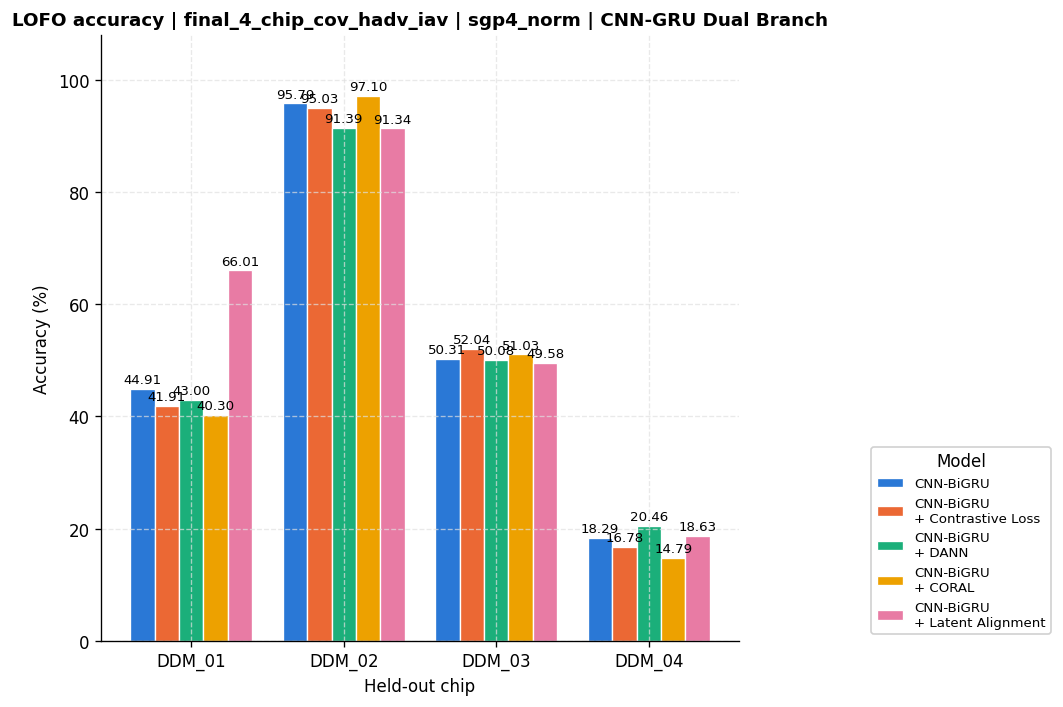

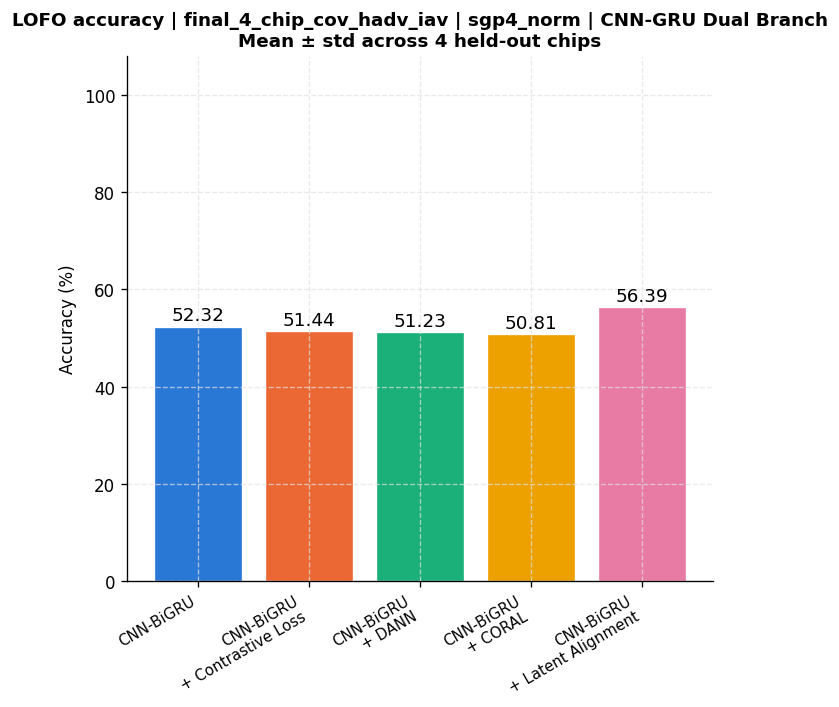

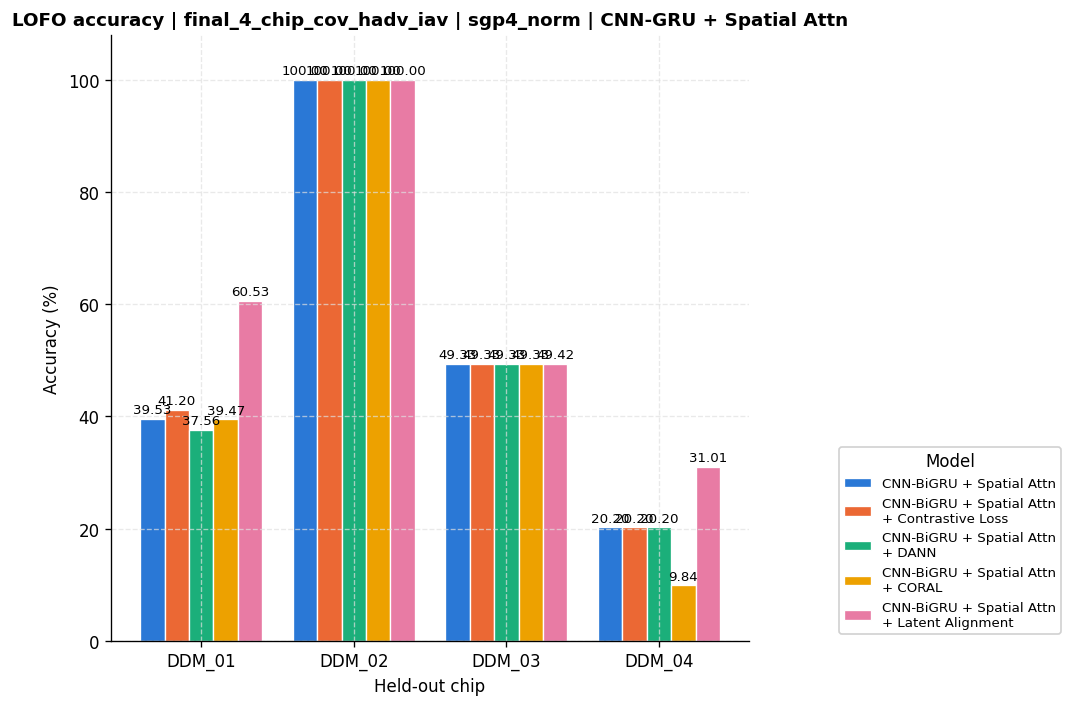

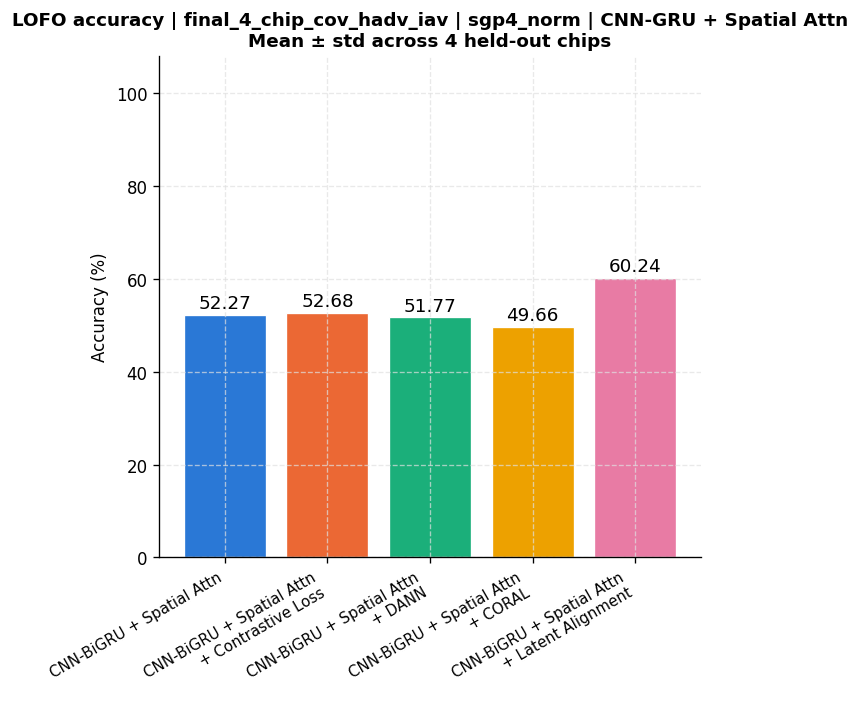

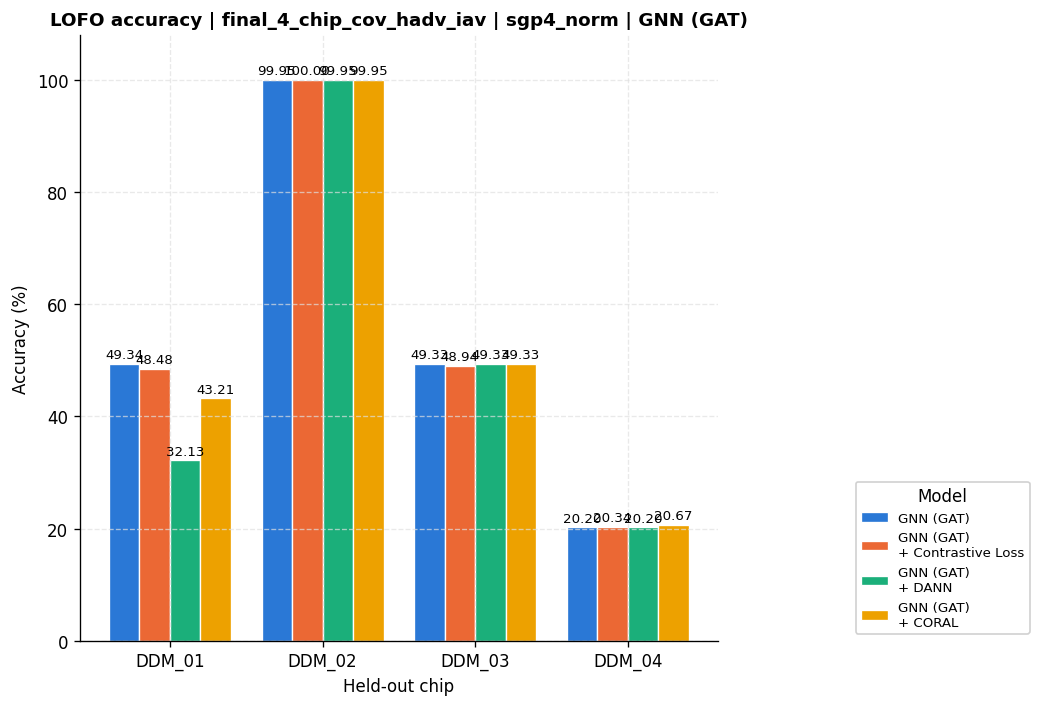

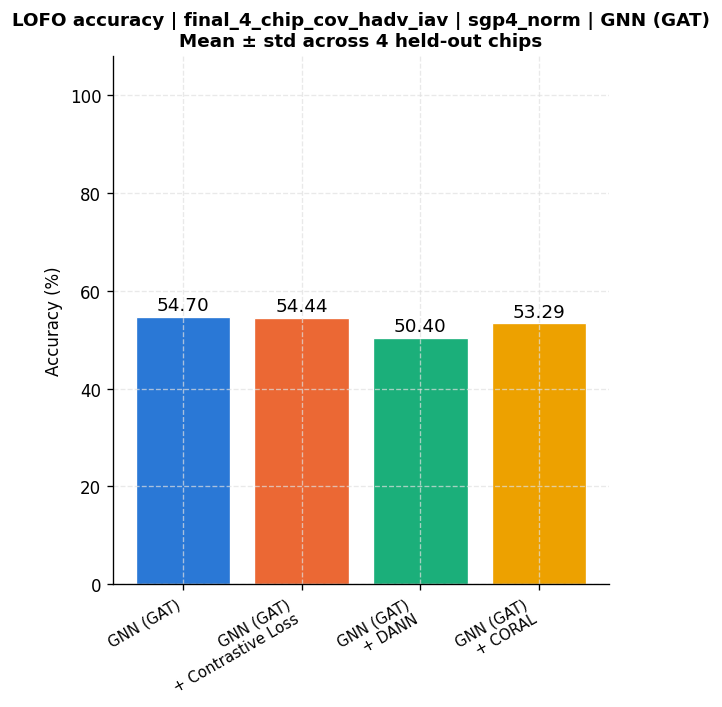

In [32]:
%matplotlib inline

# selected_held_outs = ['DDM_01']
selected_held_outs = []
if selected_held_outs:
    lofo_df_filtered = lofo_df[lofo_df['fold'].isin(selected_held_outs)].copy()
else:
    lofo_df_filtered = lofo_df.copy()

lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['curve_type'] == 'sgp4_norm']
# lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['group'].isin(['final_4_chip_clean_nn', 'final_4_chip_cov_hadv_iav'])]

for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(LOFO_COMPARISON_1, "CNN-GRU Dual Branch"),
                              (LOFO_COMPARISON_2, "CNN-GRU + Spatial Attn"),
                              (LOFO_COMPARISON_3, "GNN (GAT)")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            xlabel='Held-out chip', title=f'LOFO accuracy | {group_name} | {curve_type} | {label}',
            plot_fold=True, plot_summary=True, show_std=False,
        )
        # print(f"\nMean ± std across held-out chips ({group_name} | {curve_type} | {label}):")
        # print(stats.round(2))
    print("="*70)
